# Inference and Information Extraction

This notebook implements the **inference stage** of the Emergency Care Disruption Dataset (ECDD) pipeline.

In the previous stage of the pipeline, a web retrieval process was used to collect documents related to French hospital emergency departments using the Tavily Search API. Each hospital in the FINESS registry was used to generate targeted queries, producing a set of candidate sources (news articles, institutional communications, and press releases).

The objective of this notebook is to **analyze the retrieved documents and extract structured information about emergency department disruptions**.

Using a local large language model (**Mistral-7B-Instruct**, deployed with **vLLM**), the pipeline processes the textual content of each source and identifies relevant events such as:

- temporary emergency department closures  
- regulated access to emergency services  
- strikes affecting emergency care  
- SMUR service disruptions  

The extracted information is then converted into structured records that can be stored in a long-format dataset where **each row corresponds to a single event supported by a verifiable source URL**.

Within the overall pipeline, this notebook corresponds to the **inference** stage of the pipeline, transforming unstructured web content into machine-readable data for subsequent structuring and analysis.

In [1]:
import json
import time
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from vllm import LLM, SamplingParams

ideas:
1) https://www.youtube.com/watch?app=desktop&v=9j-480mlXEk&start=0

## Local LLM Setup: Why Mistral-7B and Why vLLM?

This notebook uses a **local large language model**, `Mistral-7B-Instruct-v0.3`, served through **vLLM**, to perform structured information extraction from the retrieved web sources. 

### Why use a local model?

A local model was preferred over an external API for three main reasons:

1. **Reproducibility**  
   Running the model locally makes the extraction pipeline easier to reproduce, since the same model version and inference settings can be reused across runs.

2. **Auditability and control**  
   The inference process remains fully controlled within the project environment. This is particularly important when processing hospital-level evidence and preserving a transparent extraction pipeline.

3. **Scalability for batch processing**  
   The task requires repeated inference over many retrieved documents. A local setup allows large batches of extractions without depending on API quotas or external service availability.

### Why `Mistral-7B-Instruct-v0.3`?

[`Mistral-7B-Instruct-v0.3`](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3) was selected as a practical compromise between **instruction-following ability**, **computational efficiency**, and **local deployability**.


This model is suitable for the current task because:

- it can follow structured prompts reliably,
- it is lightweight enough to run on local GPU infrastructure,
- it performs well for extraction-style tasks where the goal is to return concise, schema-constrained outputs rather than long-form generation.

In this notebook, the model is not used for open-ended text generation, but as a **controlled extractor** of event attributes from retrieved sources.

### Why use vLLM?

The model is served through [`vLLM`](https://github.com/vllm-project/vllm), an inference engine designed for efficient deployment of large language models.

vLLM is used here because it provides:

- **fast inference** for repeated prompt execution,
- **efficient GPU memory management**,
- a simple interface for running the model locally in batch settings.

This makes it well suited for a pipeline in which many documents must be processed sequentially or in batches.

### Inference settings

The model is loaded from disk and configured with the following parameters:

- `dtype='half'`  
  Uses half-precision floating point format to reduce GPU memory usage.

- `gpu_memory_utilization=0.5`  
  Limits the fraction of GPU memory allocated to the model, helping avoid memory saturation.

- `max_model_len=2000`  
  Restricts the maximum input context length, which is sufficient for the extraction prompts used in this notebook while remaining computationally manageable.

- `temperature=0`  
  Forces deterministic generation, which is appropriate for structured extraction tasks where consistency is preferred over creativity.

- `max_tokens=256`  
  Caps the output length, since the expected output is a short structured response rather than free-form text.



In [2]:
# Force vLLM to use the Data partition for everything
os.environ['VLLM_CONFIG_ROOT'] = '/Data/anahi_reyes/vllm_cache/config'
os.environ['VLLM_CACHE_ROOT'] = '/Data/anahi_reyes/vllm_cache'
os.environ['VLLM_NO_USAGE_STATS'] = '1'
os.environ['HF_HOME'] = '/Data/anahi_reyes/huggingface_cache'
# Forzamos el uso del motor estable (V0)
#os.environ["VLLM_USE_V1"] = "false"
# También por seguridad, evitamos que intente usar HTTP moderno si hay conflictos de red local
#os.environ["VLLM_CONFIGURE_LOGGING"] = "1"

# Load the in-disk LLM to the environment
model_path = '/Data/anahi_reyes/models/Mistral-7B-Instruct-v0.3'
llm = LLM(model=model_path, dtype='half', gpu_memory_utilization=0.8, max_model_len=4096)
sampling_params = SamplingParams(temperature=0, max_tokens=512,  stop=["</json>", "[/INST]"])


INFO 03-14 17:08:02 [utils.py:261] non-default args: {'dtype': 'half', 'max_model_len': 4096, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': '/Data/anahi_reyes/models/Mistral-7B-Instruct-v0.3'}
INFO 03-14 17:08:02 [model.py:541] Resolved architecture: MistralForCausalLM
WARNING 03-14 17:08:02 [model.py:1885] Casting torch.bfloat16 to torch.float16.
INFO 03-14 17:08:02 [model.py:1561] Using max model len 4096
INFO 03-14 17:08:02 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 03-14 17:08:02 [vllm.py:624] Asynchronous scheduling is enabled.


Multiple tokenizer files found in directory: /Data/anahi_reyes/models/Mistral-7B-Instruct-v0.3. Using tokenizer.model.v3.


(EngineCore_DP0 pid=937569) INFO 03-14 17:08:02 [core.py:96] Initializing a V1 LLM engine (v0.15.0) with config: model='/Data/anahi_reyes/models/Mistral-7B-Instruct-v0.3', speculative_config=None, tokenizer='/Data/anahi_reyes/models/Mistral-7B-Instruct-v0.3', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endp

(EngineCore_DP0 pid=937569) <frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore_DP0 pid=937569) <frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(EngineCore_DP0 pid=937569) INFO 03-14 17:08:08 [default_loader.py:291] Loading weights took 2.85 seconds
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:09 [gpu_model_runner.py:4118] Model loading took 13.51 GiB memory and 3.303761 seconds
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:15 [backends.py:805] Using cache directory: /Data/anahi_reyes/vllm_cache/torch_compile_cache/6563c897c5/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:16 [backends.py:865] Dynamo bytecode transform time: 6.23 s
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:19 [backends.py:267] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 1.304 s
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:19 [monitor.py:34] torch.compile takes 7.54 s in total
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:20 [gpu_worker.py:356] Available KV cache memory: 4.42 GiB
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:20 [kv_cache_utils.py:1307] GPU KV cache size: 36,240 tok

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 15.89it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 20.32it/s]


(EngineCore_DP0 pid=937569) INFO 03-14 17:08:26 [gpu_model_runner.py:5051] Graph capturing finished in 6 secs, took 0.51 GiB
(EngineCore_DP0 pid=937569) INFO 03-14 17:08:26 [core.py:272] init engine (profile, create kv cache, warmup model) took 16.89 seconds


(EngineCore_DP0 pid=937569) Multiple tokenizer files found in directory: /Data/anahi_reyes/models/Mistral-7B-Instruct-v0.3. Using tokenizer.model.v3.


INFO 03-14 17:08:27 [llm.py:343] Supported tasks: ['generate']


In [3]:
#df = df = pd.read_json("/Data/anahi_reyes/EDCD_data/raw_edcd_database_atomic.jsonl", lines=True)
df = pd.read_json("https://raw.githubusercontent.com/AnahiRM/PiA-DREES-2025/main/data/intermediate/raw_edcd_database_atomic.jsonl", lines=True)
df.head()

,finess,hospital_name,nom_etab_long,keywords_nom_etab,source_url,title,content,score,retrieved_at
0,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://clinique-convert-bourg-en-bresse.ramsa...,Fermeture temporaire des Urgences - Clinique C...,Avant de venir\n\n + Conseils pratiques de A ...,0.672182,2026-03-14 11:50:40
1,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://www.leprogres.fr/sante/2025/10/16/urge...,Ain. Urgences de l'hôpital de Bourg-en-Bresse ...,"Le 31 janvier dernier, les urgences du centre ...",0.596833,2026-03-14 11:50:40
2,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://www.hopital.fr/annuaire-service/urgenc...,Bourg-en-Bresse (site de Fleyriat) Urgences,Bourg-en-Bresse\n\n# Bourg-en-Bresse (site de ...,0.572078,2026-03-14 11:50:40
3,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://www.radioscoop.com/infos/bientot-la-fi...,Bientôt la fin des restrictions aux urgences d...,SÉLECTIONNEZ VOTRE VILLE\n\nRhône\n\n Lyon\n T...,0.554206,2026-03-14 11:50:40
4,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://www.facebook.com/leprogres.ain/posts/%...,Cette décision a été prise en concertation ave...,View all 39 replies\n\nTop fan\n\nSylvie Vasse...,0.531234,2026-03-14 11:50:40


In [4]:
def build_extraction_prompt(row):
    h_name = row['hospital_name']
    h_keywords = row['keywords_nom_etab']
    return f"""<s>[INST]
You are a structured data extraction assistant specializing in French healthcare disruptions.

TARGET HOSPITAL:
- Official name: "{h_name}"
- Also known as: "{h_keywords}"
- Match even with abbreviations or partial names.
- Do NOT match other hospitals sharing only a generic word like "CHU" or "Centre".

TASK:
Determine whether THIS TARGET HOSPITAL's emergency department (Urgences) is experiencing
a confirmed disruption, a potential disruption, or neither.

Set relevant = true if the article explicitly states that the urgences are:
- Closed (fully or partially, day or night)
- Operating with reduced staffing or reorganized access
- Regulated (patients must call before coming)
- Redirecting ambulances
- The article describes a past disruption that has now ended — the event still occurred and should be captured.

Set relevant = "potential" if no disruption has been implemented yet, but the article
explicitly describes a direct threat to the urgences:
- Documented staff shortage or upcoming reorganization
- ARS intervention or administrative crisis specifically affecting the urgences
- Political motions or demands specifically about the urgences

Set relevant = false in all other cases, including:
- General hospital tensions without specific urgences impact
- Disruptions in other departments (surgery, maternity, psychiatry, etc.)
- The hospital appears only as a backup/receiving hospital
- Proposals or debates with nothing implemented yet

When in doubt, prefer false over true or potential.

ROLE IDENTIFICATION:
STEP 1: Copy the exact name of the hospital whose urgences are closing, regulated, or at risk.
STEP 2: Does that name contain "{h_name}" or "{h_keywords}"?
        - Yes → proceed to assess relevant = true or "potential"
        - No → relevant = false, regardless of whether the target hospital is mentioned elsewhere.
STEP 3: If the TARGET HOSPITAL is mentioned only as receiving patients, it is OPEN → relevant = false.

TEMPORAL REASONING:
- The publication date may appear in the URL (e.g. /2024/03/15/ or /2024-03-15/).
- If only month and year are known, use the first of the month: "2022-07-01".
- If found in the URL, use it as the publication date.
- If also present in the article text, prefer the article text date.
- WARNING: ignore dates found in unrelated links, footers, or "related articles" sections.
- Use it to resolve relative expressions: "today", "this weekend", "from Monday".
- If no publication date is found, leave relative expressions as "Unknown" — do not guess.
- end_date = "Ongoing" only if the article explicitly says no end date is set.
- end_date = "Unknown" if a closure is mentioned but no end date is given.
- end_date = "YYYY-MM-DD" if a specific date is stated or clearly implied.

OUTPUT:
First write 1-2 sentences explaining your decision.
Then output the result in a <json> block.

Confirmed disruption case:
<json>
{{
  "relevant": true,
  "status": "YOU MUST COPY EXACTLY ONE OF THESE OPTIONS VERBATIM — Fermeture complète OR Fermeture temporaire OR Régulation des entrées OR Détournement ambulances OR Unknown",
  "start_date": "YOU MUST COPY EXACTLY ONE OF THESE FORMATS VERBATIM — YYYY-MM-DD OR Unknown",
  "end_date": "YOU MUST COPY EXACTLY ONE OF THESE FORMATS VERBATIM — YYYY-MM-DD OR Ongoing OR Unknown",
  "reason": "Free text — describe the cause of the disruption as mentioned in the article. Unknown if not mentioned.",
  "publication_date": "YOU MUST COPY EXACTLY ONE OF THESE FORMATS VERBATIM — YYYY-MM-DD OR Unknown",
  "confidence": "YOU MUST COPY EXACTLY ONE OF THESE OPTIONS VERBATIM — High OR Medium OR Low"
}}
</json>

Potential disruption case:
<json>
{{
  "relevant": "potential",
  "risk_description": "Free text — describe what situation puts the urgences at risk.",
  "publication_date": "YOU MUST COPY EXACTLY ONE OF THESE FORMATS VERBATIM — YYYY-MM-DD OR Unknown",
  "confidence": "YOU MUST COPY EXACTLY ONE OF THESE OPTIONS VERBATIM — High OR Medium OR Low"
}}
</json>

Non-relevant case:
<json>{{"relevant": false}}</json>

TEXT:
URL: {row['source_url']}
Title: {row['title']}
Content: {row['content']}
[/INST]"""

#def hospital_mention_score(row):
    content = str(row['content']).lower()
    title = str(row['title']).lower()
    name = str(row['hospital_name']).lower()
    keywords = str(row['keywords_nom_etab']).lower()
    nom_long = str(row['nom_etab_long']).lower()
    
    generic = {'de', 'du', 'le', 'la', 'les', 'en', 'et', 'ch',
               'centre', 'hospitalier', 'clinique', 'hopital', 'none',
               'chu', 'ght', 'ghm', 'chi', 'chl'}
    
    all_names = name + ' ' + keywords + ' ' + nom_long
    target_words = {w for w in set(all_names.split()) - generic if len(w) > 4}
    
    text = content + ' ' + title
    matches = sum(1 for word in target_words if word in text)
    return matches

def robust_json_parse(raw_output):
    match = re.search(r'<json>(.*?)</json>', raw_output, re.DOTALL)
    if not match:
        match = re.search(r'(\{.*\})', raw_output, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1).strip())
        except json.JSONDecodeError as e:
            return {"relevant": False, "parsing_error": True, "error_msg": str(e), "raw": raw_output[:200]}
    return {"relevant": False, "no_json_found": True, "raw": raw_output[:200]}

# Execution
#prompts = df.apply(build_extraction_prompt, axis=1).tolist()
#responses = llm.generate(prompts, sampling_params)

#df_ext = pd.DataFrame([robust_json_parse(r.outputs[0].text) for r in responses])

In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_json(
    "https://raw.githubusercontent.com/AnahiRM/PiA-DREES-2025/main/data/intermediate/raw_edcd_database_atomic.jsonl",
    lines=True
)
print(f"Total rows loaded: {len(df)}")

# ── Pre-filter: only rows where target hospital is mentioned in content/title ──
# NOTE: Current limitation — uses exact keyword matching on words > 4 chars.
# This may miss informal references on social media (e.g. "l'hosto de Brive").
# Proposed next step: replace with fuzzy matching or city-name extraction.
#def mentions_target_hospital(row):
#    content = str(row['content']).lower()
#    title = str(row['title']).lower()
#    name = str(row['hospital_name']).lower()
#    keywords = str(row['keywords_nom_etab']).lower()
#    nom_long = str(row.get('nom_etab_long', '')).lower()

#    generic = {'de', 'du', 'le', 'la', 'les', 'en', 'et', 'ch',
#               'centre', 'hospitalier', 'clinique', 'hopital', 'none',
#               'chu', 'ght', 'ghm', 'chi', 'chl'}

#    all_names = name + ' ' + keywords + ' ' + nom_long
#    target_words = {w for w in set(all_names.split()) - generic if len(w) > 4}

#    text = content + ' ' + title
#    return any(word in text for word in target_words)

#df_filtered = df[df.apply(mentions_target_hospital, axis=1)].reset_index(drop=True)
#print(f"Rows after pre-filter: {len(df_filtered)} / {len(df)}")

# ── Truncate content to avoid exceeding max_model_len ─────────────────────────
#df_filtered = df_filtered.copy()
#df_filtered['content'] = df_filtered['content'].str[:8000]

# ── Checkpointing: skip already processed rows ────────────────────────────────
output_path = "/Data/anahi_reyes/EDCD_data/llm_output.jsonl"

already_processed = set()
try:
    df_existing = pd.read_json(output_path, lines=True)
    already_processed = set(df_existing['source_url'].tolist())
    print(f"Resuming — {len(already_processed)} rows already processed")
except Exception:
    print("No existing output found, starting fresh")

df_to_process = df[~df['source_url'].isin(already_processed)].reset_index(drop=True)
print(f"Rows to process: {len(df_to_process)}")

# ── LLM inference ──────────────────────────────────────────────────────────────
prompts = df_to_process.apply(build_extraction_prompt, axis=1).tolist()
responses = llm.generate(prompts, sampling_params)

# ── Parse and save incrementally ──────────────────────────────────────────────
results = []
for i, r in enumerate(responses):
    parsed = robust_json_parse(r.outputs[0].text)
    entry = {**df_to_process.iloc[i].to_dict(), **parsed}
    results.append(entry)

    # Save every 100 rows as checkpoint
    if (i + 1) % 100 == 0:
        pd.DataFrame(results).to_json(output_path, orient='records', lines=True, mode='a', force_ascii=False)
        results = []
        print(f"Checkpoint saved at row {i + 1}")

# Save remaining
if results:
    pd.DataFrame(results).to_json(output_path, orient='records', lines=True, mode='a', force_ascii=False)

print(f"Done. Output saved to {output_path}")

# ── Build final dataframe ──────────────────────────────────────────────────────
df_final = pd.read_json(output_path, lines=True)
print(f"Total rows in output: {len(df_final)}")
print(f"Relevant disruptions: {df_final['relevant'].value_counts().to_dict()}")

Total rows loaded: 6072
No existing output found, starting fresh
Rows to process: 6072


/tmp/ipykernel_937290/3100600377.py:41: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_existing = pd.read_json(output_path, lines=True)


Adding requests:   0%|          | 0/6072 [00:00<?, ?it/s]

/users/eleves-b/2024/anahi.reyes-miguel/miniconda3/envs/vllm_env/lib/python3.10/site-packages/mistral_common/tokens/tokenizers/sentencepiece.py:133: FutureWarning: `get_control_token` is deprecated. Use `get_special_token` instead.
  warnings.warn("`get_control_token` is deprecated. Use `get_special_token` instead.", FutureWarning)


Processed prompts:   0%|          | 0/6072 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

In [69]:
pd.set_option('display.max_columns', None)
df_final.head()

,finess,hospital_name,nom_etab_long,keywords_nom_etab,source_url,title,content,score,retrieved_at,relevant,status,start_date,end_date,reason,publication_date,confidence,risk_description,no_json_found,raw,explanation,urgences_status,parsing_error,error_msg,disruption_status,disruption_duration
0,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://clinique-convert-bourg-en-bresse.ramsaysante.fr/actualites/fermeture-temporaire-des-urgences,Fermeture temporaire des Urgences - Clinique Convert,"Avant de venir\n\n + Conseils pratiques de A à Z\n Plan d'accès\n\n Rechercher\n\n# Actualités\n\n## Fermeture temporaire des Urgences\n\nle 11/07/2025\n\nRetour\n\nLe service des urgences de notre établissement fermera temporairement l’accueil de nuit du vendredi 11 juillet à 17h00 au mercredi 16 juillet à 8h00.\n\nDurant cette période, les urgences seront ouvertes chaque jour de 8h00 à 17h00.\n\nLes urgences cardiologiques restent assurées.\n\nPendant cette période, Il est demandé aux patients de se présenter au centre hospitalier de Fleyriat. Celui-ci recevra le renfort des médecins urgentistes de la Clinique Ramsay Convert. [...] - Préparez votre séjour\n - Votre sortie\n + Droits du patient\n\n - Vos droits et devoirs\n - Les représentants des usagers\n - Votre dossier médical\n - Lettre du pharmacien au patient : information sur votre prise en charge médicamenteuse\n Trouver un médecin\n Vous êtes accompagnant\n\n + Se rendre facilement à la clinique Convert\n\n - Comment venir à la clinique Convert ?\n - Les visites\n + Sur place\n Informations pratiques\n\n + Avant de venir\n\n - Conseils pratiques de A à Z\n + Plan d'accès\n\nMon compte Ramsay Services\n\n Bienvenue à la Clinique Convert\n Découvrez la clinique Convert\n\n + La clinique Convert : un établissement de soins pluridisciplinaire de proximité\n Nos compétences\n NOTRE PHILOSOPHIE [...] Aller au contenu principal \n\nRamsay Santé Clinique Convert\n\nMon compte Ramsay Services\n\n Présentation établissement\n\n + Bienvenue à la Clinique Convert\n + Découvrez la clinique Convert\n\n - La clinique Convert : un établissement de soins pluridisciplinaire de proximité\n + Nos compétences\n + NOTRE PHILOSOPHIE\n\n - Le suivi patient\n - La certification de la Haute Autorité de Santé\n + Qualité / gestion des risques\n\n - La Démarche Qualité\n - La prévention des risques\n Vous êtes patient\n\n + Pourquoi choisir Ramsay Générale de Santé ?\n\n - Nos prises en charge\n - Tous nos soins\n - Nos Services\n + Votre hospitalisation\n\n - Hospitalisation en chirurgie\n - Hospitalisation en médecine\n - Vos frais d'hospitalisation\n + Votre séjour à la clinique Convert",0.672182,2026-03-14 11:50:40,True,Fermeture temporaire,2025-07-11,2025-07-16,"The urgent care service will temporarily close the night shift from July 11, 2025, at 5:00 PM to July 16, 2025, at 8:00 AM. During this period, the urgences will be open every day from 8:00 AM to 5:00 PM. The cardiology urgences remain assured. During this period, it is required that patients present themselves at the Fleyriat hospital. This hospital will receive the reinforcement of the urgent care doctors from the Clinique Ramsay Convert.",2025-07-11,High,None,NaN,None,None,NaN,NaN,NaN,NaN,NaN
1,010000024,CH DE FLEYRIAT,CENTRE HOSPITALIER DE BOURG-EN-BRESSE FLEYRIAT,BOURG-EN-BRESSE FLEYRIAT,https://www.leprogres.fr/sante/2025/10/16/urgences-de-l-hopital-de-bourg-en-bresse-le-retour-a-la-normale-annonce-apres-dix-mois-de-restrictions,Ain. Urgences de l'hôpital de Bourg-en-Bresse - Le Progrès,"Le 31 janvier dernier, les urgences du centre hospitalier de Bourg-en-Bresse (CHB) étaient réorganisées du vendredi soir et jusqu’au dimanche matin. De 17 heures à 8 heures le lendemain, le service tournait en effectif réduit avec deux médecins urgentistes en poste, dont celui du Samu, contre quatre en temps normal. Cette décision avait été prise après une longue réflexion de l’établissement qui constata

In [70]:
df_final.shape

(6072, 25)

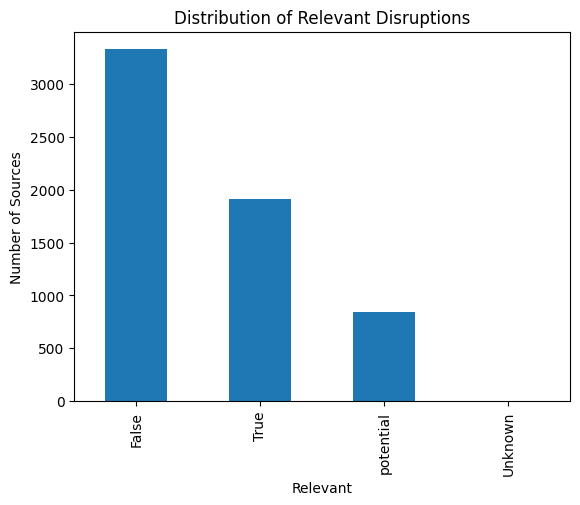

In [ ]:
# Count values
relevant_counts = df_final["relevant"].value_counts(dropna=False)

# Compute percentages
total = relevant_counts.sum()
percentages = relevant_counts / total * 100

# Plot
plt.figure()
ax = relevant_counts.plot(kind="bar")

plt.title("Distribution of Relevant Disruptions")
plt.xlabel("Relevant")
plt.ylabel("Number of Sources")

# Add percentages on top of bars
for i, (count, pct) in enumerate(zip(relevant_counts, percentages)):
    ax.text(i, count, f"{pct:.1f}%", ha='center', va='bottom')

plt.show()

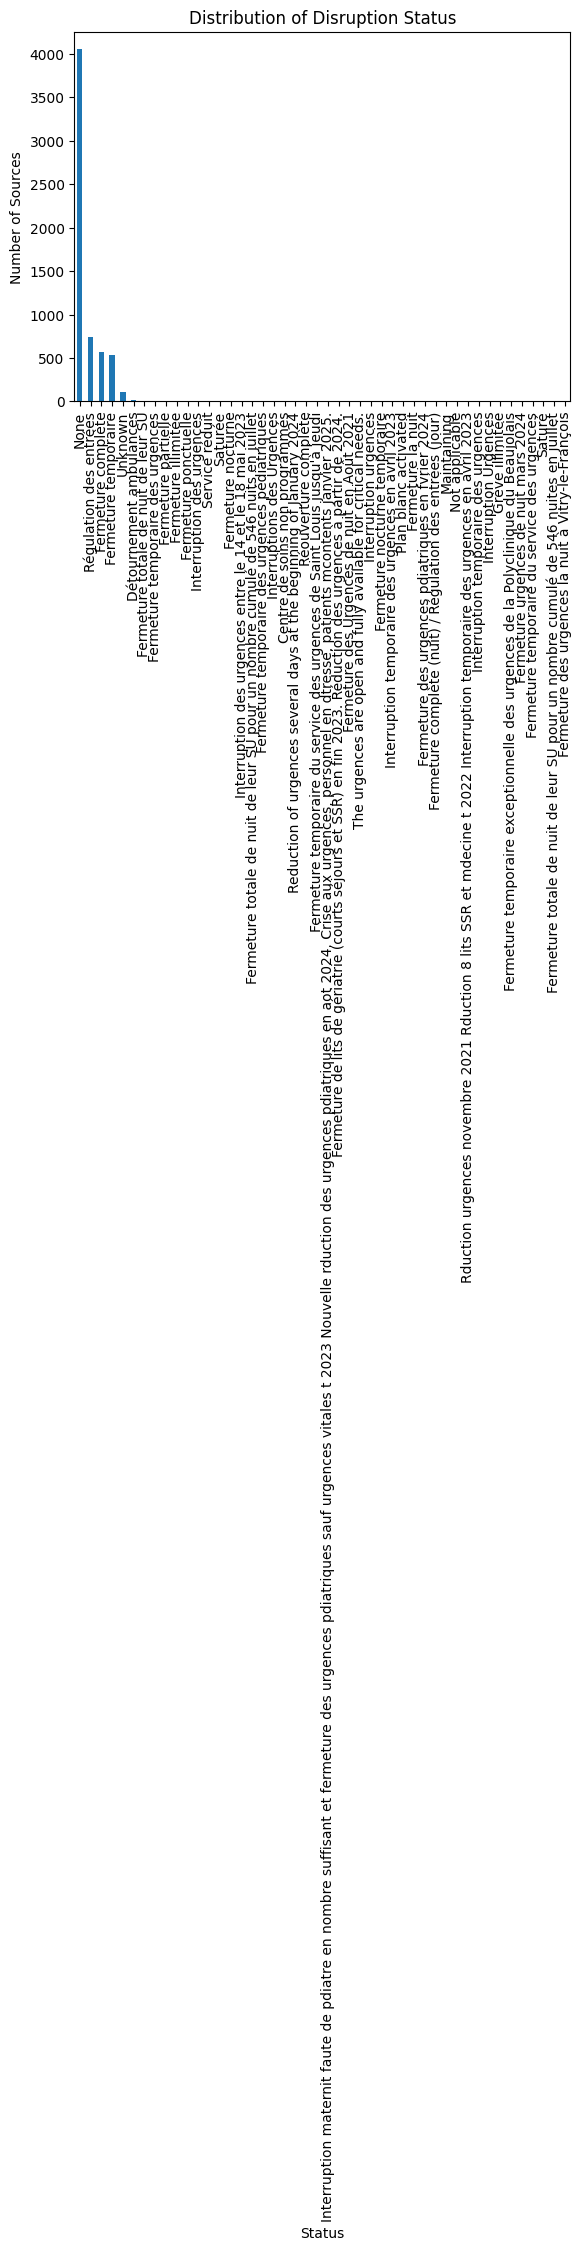

In [ ]:
# Count values
status_counts = df_final["status"].value_counts(dropna=False)

# Compute percentages
total = status_counts.sum()
percentages = status_counts / total * 100

# Plot
plt.figure()
ax = status_counts.plot(kind="bar")

plt.title("Distribution of Disruption Status")
plt.xlabel("Status")
plt.ylabel("Number of Sources")

# Add percentages on top of bars
for i, (count, pct) in enumerate(zip(status_counts, percentages)):
    ax.text(i, count, f"{pct:.1f}%", ha="center", va="bottom")

plt.show()

In [65]:
df_final["status"].unique()

array(['Fermeture temporaire', None, 'Régulation des entrées',
       'Fermeture complète', 'Fermeture temporaire des urgences',
       'Unknown', 'Fermeture totale de nuit de leur SU',
       'Reduction of urgences several days at the beginning of January 2024',
       'Réouverture complète', 'Interruption des urgences', 'Saturée',
       'Centre de soins non programmés', 'Service réduit',
       'Interruptions des Urgences',
       'Interruption temporaire des urgences en avril 2023',
       'Interruption maternit faute de pdiatre en nombre suffisant et fermeture des urgences pdiatriques sauf urgences vitales t 2023 Nouvelle rduction des urgences pdiatriques en aot 2024. Crise aux urgences, personnel en dtresse, patients mcontents janvier 2025.',
       'Fermeture de lits de gériatrie (courts séjours et SSR) en fin 2023. Réduction des urgences à partir de 2024.',
       'Fermeture des Urgences de nuit en Août 2021',
       'Fermeture ponctuelle', 'Fermeture partielle',
       'Fermet